In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from scipy.io import loadmat  ### use this to load .mat files

In [3]:
A = loadmat('VORTALL.mat')  ### load the .mat file
print(A.keys())  ### print the keys of the dictionary to see what is inside
K = A['VORTALL']  ### extract the variable from the dictionary 
print(K.shape)
print(K)  ### print the variable to see what it looks like


dict_keys(['__header__', '__version__', '__globals__', 'VORTALL'])
(89351, 151)
[[-5.92220e-15 -4.68318e-15 -2.94902e-15 ... -9.62025e-15 -8.86421e-15
  -7.27853e-15]
 [-6.01624e-15 -4.61205e-15 -2.58238e-15 ... -9.57891e-15 -8.89550e-15
  -7.31406e-15]
 [-5.92116e-15 -4.68413e-15 -2.50956e-15 ... -9.98390e-15 -8.95430e-15
  -7.50686e-15]
 ...
 [-1.47386e-02 -5.92327e-03 -1.69510e-03 ... -3.54696e-02 -3.64824e-02
  -2.84128e-02]
 [-1.36956e-02 -5.31169e-03 -1.47472e-03 ... -4.07780e-02 -3.80910e-02
  -2.78294e-02]
 [-1.26353e-02 -4.73980e-03 -1.27796e-03 ... -4.49435e-02 -3.89362e-02
  -2.69284e-02]]


In [4]:
frame1 = K[:,0].reshape(199,449, order='F')
print(frame1.shape )



(199, 449)


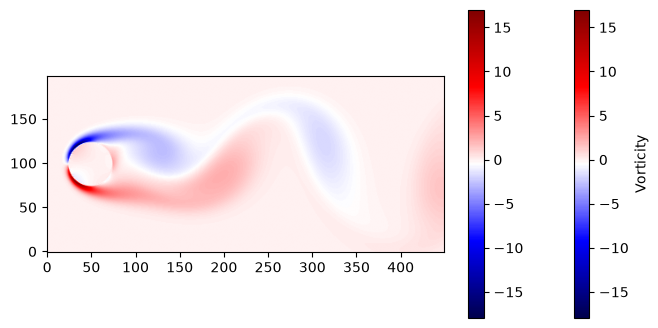

In [5]:
plt.figure(figsize=(8,4))
plt.imshow(frame1, cmap='seismic', origin='lower')
plt.colorbar(label='Vorticity')
plt.colorbar()
plt.show()

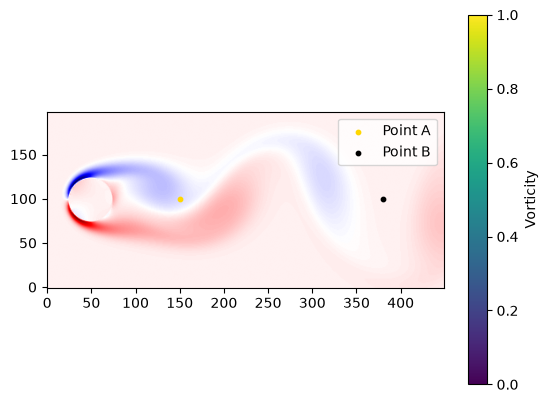

In [6]:
plt.Figure(figsize=(8,4))
plt.imshow(frame1,cmap='seismic', origin='lower')
plt.scatter(150,100,color='gold',s=10,label='Point A')
plt.scatter(380,100,color='Black',s=10,label='Point B')
plt.legend()
plt.colorbar(label='Vorticity')
plt.show()
plt.show()

In [7]:
K3 =K.reshape(199,449,151,order='F')
K3.shape

(199, 449, 151)

In [8]:
ptA=K3[100,150,:]
ptB=K3[100,380,:]
t = np.arange(151)*0.1

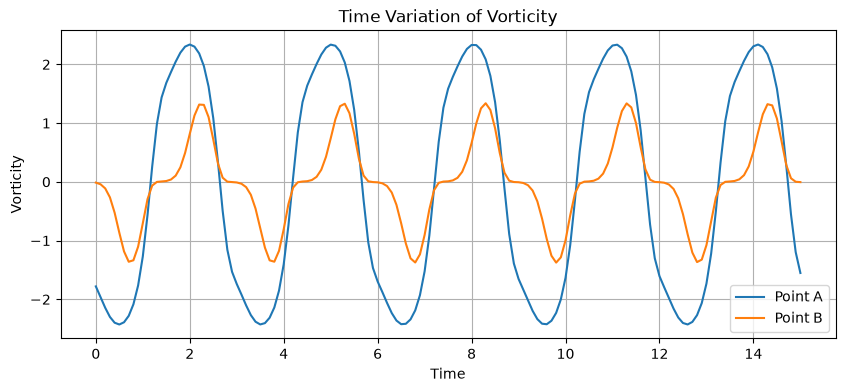

In [9]:
plt.figure(figsize=(10,4))

plt.plot(t,ptA,label='Point A')
plt.plot(t,ptB,label='Point B')

plt.xlabel('Time')
plt.ylabel('Vorticity')
plt.title('Time Variation of Vorticity')
plt.legend()
plt.grid(True)

plt.show()

In [15]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

fig, ax = plt.subplots(figsize=(8,4))

frame = K[:,0].reshape(199,449,order='F')

im = ax.imshow(frame,
               cmap='seismic',
               origin='lower',
               aspect='auto')

plt.colorbar(im, ax=ax)

def update(i):

    frame = K[:,i].reshape(199,449,order='F')

    im.set_data(frame)

    ax.set_title(f"Time = {i*0.1:.2f} s")

    return [im]

ani = FuncAnimation(fig,
                    update,
                    frames=151,
                    interval=100,
                    blit=True)

writer = FFMpegWriter(fps=10)

ani.save("vorticity1.mp4", writer=writer)

plt.close()

print("Video saved successfully!")

Video saved successfully!


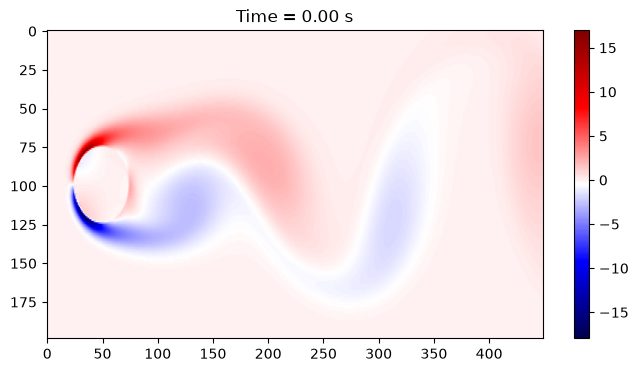

In [16]:
# it the K matrix without PCA i.e without taking mean substraction 

fig, ax = plt.subplots(figsize=(8,4))

frame = K[:, 0].reshape(199, 449, order='F')

im = ax.imshow(frame, cmap='seismic', aspect='auto')

plt.colorbar(im, ax=ax)

for i in range(151):

    frame = K[:, i].reshape(199, 449, order='F')

    im.set_data(frame)        # Update only the image
    time = i * 0.1
    ax.set_title("Time = {:.2f} s".format(time))

    plt.pause(0.01)

plt.show()


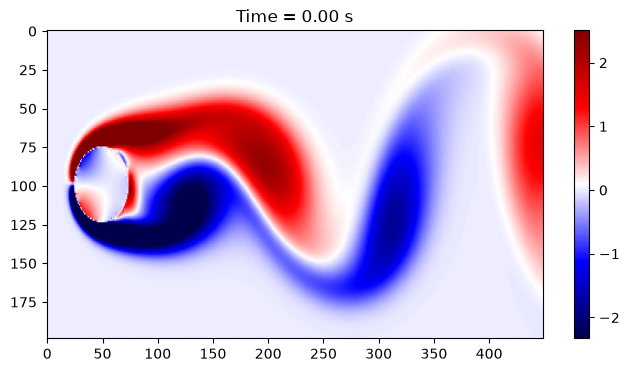

In [17]:
K_mean = np.mean(K, axis=1, keepdims=True)
K_fluct = K - K_mean


# with mean

fig, ax = plt.subplots(figsize=(8,4))

frame =K_fluct[:, 0].reshape(199, 449, order='F')

im = ax.imshow(frame, cmap='seismic', aspect='auto')

plt.colorbar(im, ax=ax)

for i in range(151):

    frame = K[:, i].reshape(199, 449, order='F')

    im.set_data(frame)        # Update only the image
    time = i * 0.1
    ax.set_title("Time = {:.2f} s".format(time))

    plt.pause(0.01)

plt.show()

In [18]:


fig, ax = plt.subplots(figsize=(8,4))

frame = K_fluct[:,0].reshape(199,449,order='F')

im = ax.imshow(frame,
               cmap='seismic',
               origin='lower',
               aspect='auto')

plt.colorbar(im, ax=ax)

def update(i):

    frame = K[:,i].reshape(199,449,order='F')

    im.set_data(frame)

    ax.set_title(f"Time = {i*0.1:.2f} s")

    return [im]

ani = FuncAnimation(fig,
                    update,
                    frames=151,
                    interval=100,
                    blit=True)

writer = FFMpegWriter(fps=10)

ani.save("vorticity2.mp4", writer=writer)

plt.close()

print("Video saved successfully!")

Video saved successfully!


In [24]:
U , S ,VT = np.linalg.svd(K_fluct, full_matrices=False)
print(U)
print(S)
print(VT)
print(U.shape)
print(S.shape)
print(VT.shape)

[[ 7.83848903e-16 -1.97367819e-16 -1.33550352e-16 ... -2.52118604e-10
   1.86816037e-10  1.17510735e-01]
 [ 3.68980272e-17 -1.37631437e-16  1.41069793e-16 ...  1.10173493e-10
   2.45923831e-10 -2.24444796e-02]
 [ 7.05621155e-17 -7.95527450e-17 -1.03045926e-16 ... -1.27252027e-10
   6.70635838e-11 -4.69940022e-03]
 ...
 [ 5.12855312e-04 -6.26847821e-04 -3.27189288e-04 ... -9.95279888e-04
   6.18435578e-06 -1.63819013e-04]
 [ 4.70249606e-04 -6.53920334e-04 -4.23245975e-04 ... -6.23998759e-04
   7.08327398e-04  3.72454527e-04]
 [ 4.29305617e-04 -6.77441420e-04 -5.15073934e-04 ...  4.29362511e-04
   1.59412169e-04 -5.78034378e-04]]
[1.29817039e+03 1.27964570e+03 4.66791993e+02 4.63943252e+02
 3.65751035e+02 3.58025504e+02 1.45996978e+02 1.45112813e+02
 7.71372249e+01 7.68813214e+01 3.74531201e+01 3.73441976e+01
 2.18241407e+01 2.17577429e+01 1.24266131e+01 1.23655126e+01
 6.91246851e+00 6.88767488e+00 3.60453710e+00 3.59081509e+00
 1.91946271e+00 1.91508716e+00 9.87731653e-01 9.84806067e-0

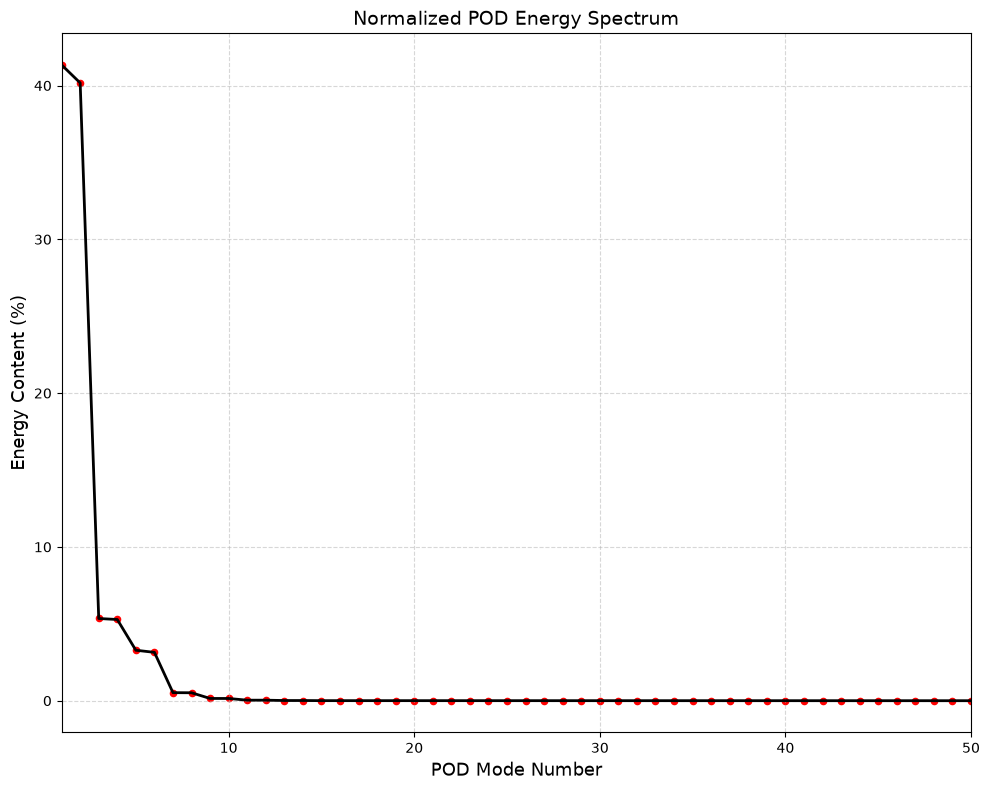

In [25]:
## E is propotional to sigma^2
E = S**2
E.shape
E_norm = E/np.sum(E)
mode =np.arange(1,len(S+1))


# POD Energy
energy = S**2
energy = energy / np.sum(energy)

mode = np.arange(1, len(S)+1)

plt.figure(figsize=(10,8))

plt.plot(mode, energy*100,color='black', linewidth=2)

plt.scatter(mode, energy*100, color='red', s=20)

plt.xlim(1,50)        # Show first 50 modes

plt.xlabel('POD Mode Number', fontsize=13)
plt.ylabel('Energy Content (%)', fontsize=13)
plt.title('Normalized POD Energy Spectrum', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

(199, 449)


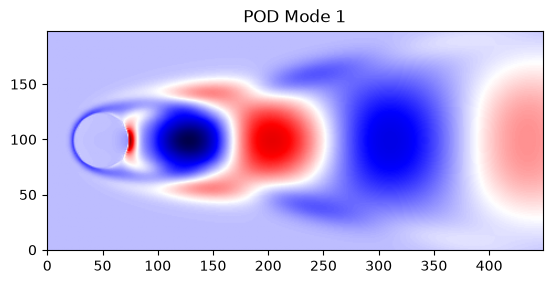

In [26]:
mode1=U[:,0].reshape(199,449,order='F')
print(mode1.shape)
plt.Figure(figsize=(10,6))
plt.imshow(mode1,cmap='seismic', origin='lower')
plt.title("POD Mode 1")
plt.show()

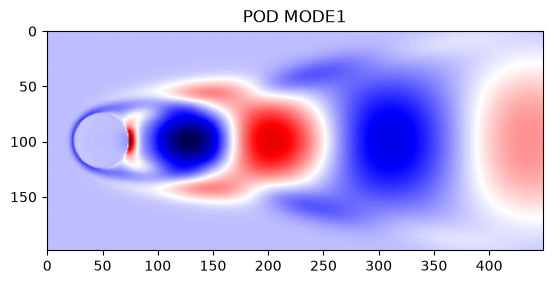

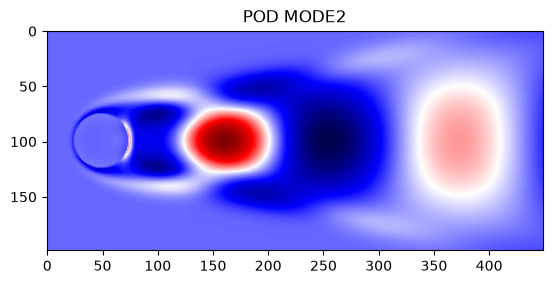

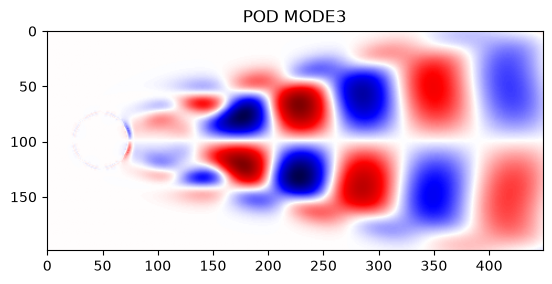

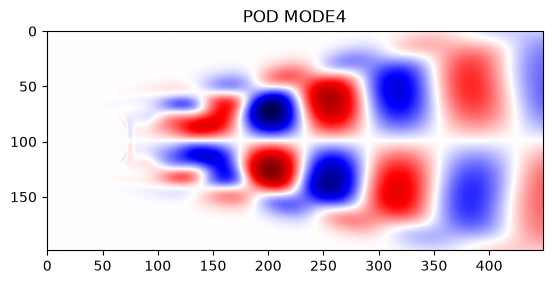

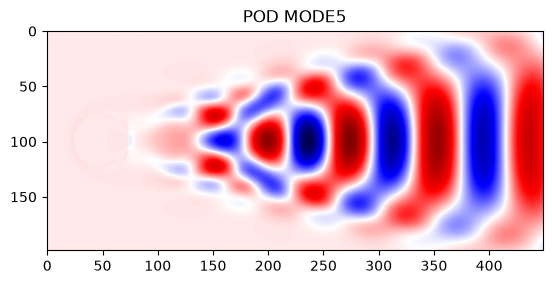

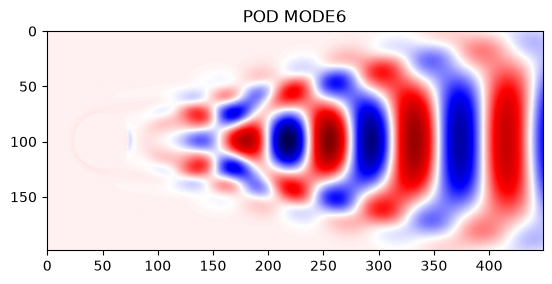

In [27]:


for i in range(6):
    mode =U[:,i].reshape(199,449,order='F')
    plt.Figure(figsize=(10,8))
    plt.imshow(mode,cmap='seismic')
    plt.colorbar
    plt.title(f'POD MODE{i+1}')
    plt.show()

In [36]:
r = 6
u_r =U[:,:r]
s_r =np.diag(S[:r])
vt_r = VT[:r,:]
K_rec = u_r @ s_r @ vt_r
print(u_r.shape)
print(s_r.shape)
print(vt_r.shape)
print(vt_r.shape)



(89351, 6)
(6, 6)
(6, 151)
(6, 151)


In [37]:
snapshot = 50

original = K_fluct[:, snapshot].reshape(199, 449, order='F')
reconstructed = K_rec[:, snapshot].reshape(199, 449, order='F')


Text(0.5, 1.0, 'Reconstructed r Modes)')

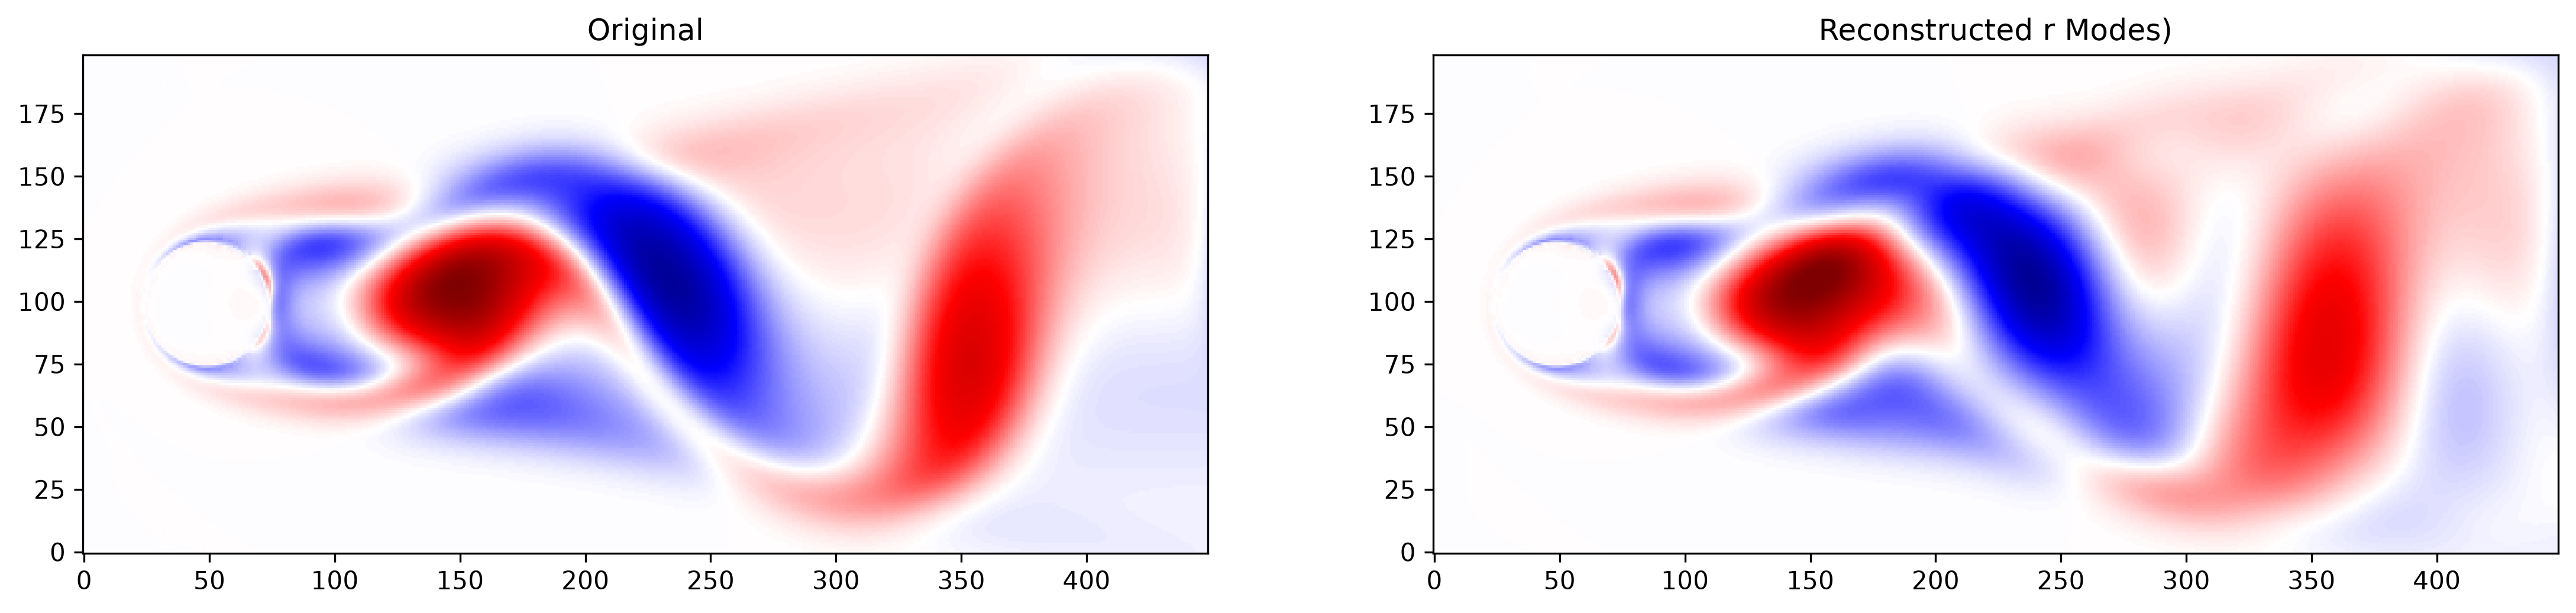

In [38]:
fig, ax = plt.subplots(1, 2,figsize=(18, 5), dpi=300)

# Use the same color limits for fair comparison
vmax = np.max(np.abs(original))

# Original
im1 = ax[0].imshow(original,
                   cmap='seismic',
                   origin='lower',
                   vmin=-vmax,
                   vmax=vmax)
ax[0].set_title('Original')

# Reconstructed
im2 = ax[1].imshow(reconstructed,
                   cmap='seismic',
                   origin='lower',
                   vmin=-vmax,
                   vmax=vmax)
ax[1].set_title('Reconstructed r Modes)')


In [40]:
error = np.linalg.norm(K_fluct- K_rec, 'fro') / np.linalg.norm(K, 'fro')   #using foribinus norm im short magnitude of all elemnts from mat 

print("Relative Reconstruction Error =", error)

Relative Reconstruction Error = 0.05885954879798124


In [42]:
fig, ax = plt.subplots(1, 2, figsize=(18,5))

frame1 = K_fluct[:,0].reshape(199,449,order='F')
frame2 = K_rec[:,0].reshape(199,449,order='F')

im1 = ax[0].imshow(frame1,cmap='seismic', origin='lower', aspect='auto',)
im2 = ax[1].imshow(frame2,cmap='seismic', origin='lower', aspect='auto',)

ax[0].set_title("Original (Fluctuating)")
ax[1].set_title("Reconstructed")

plt.colorbar(im1,ax=ax[0],shrink =0.8)
plt.colorbar(im2,ax=ax[1],shrink =0.8)

def update(i):
     frame1 = K_fluct[:,i].reshape(199,449,order='F')
     frame2 = K_rec[:,i].reshape(199,449,order='F')
     im1.set_data(frame1)
     im2.set_data(frame2)
     ax[0].set_title(f"Original   Time = {i*0.1:.2f} s")
     ax[1].set_title(f"Reconstructed   Time = {i*0.1:.2f} s")
     return im1, im2

ani = FuncAnimation(fig,update,frames=151,interval=100, blit=True)
writer = FFMpegWriter(fps=10)

ani.save("Original_vs_Reconstructed.mp4",
         writer=writer,
         dpi=200)

plt.close()

print("Video saved successfully!")


Video saved successfully!
